# Install Required Modules

In [1]:
# !pip install numpy==1.23.5

In [2]:
# !pip install ccxt
# !pip install pandas_ta

# Import Modules

In [ ]:
import pandas_ta as ta

In [2]:
import ccxt
import pandas as pd
import time
import requests
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import os

# Making our Dataset

## Function to Fetch Hourly Coin Data from Mexc Exchange

In [4]:
# def fetch_hourly_data(exchange, symbols, start_dates, timeframe='1h'):
#     """
#     Fetch hourly OHLCV data for multiple symbols starting from different dates,
#     and skip symbols that have been successfully fetched.

#     Parameters:
#     exchange (ccxt.Exchange): The initialized exchange object.
#     symbols (list): List of symbols to fetch data for.
#     start_dates (list): List of start dates in 'YYYY-MM-DD HH:MM:SS' format.
#     timeframe (str): The timeframe for OHLCV data (default is '1h').

#     Returns:
#     pd.DataFrame: A DataFrame containing OHLCV data for all symbols with an additional 'symbol' column.
#     """
#     all_data = []
#     processed_symbols = set()  # Track symbols that have been processed

#     for symbol in symbols:
#         for start_date in start_dates:
#             if symbol in processed_symbols:
#                 break

#             since = int(pd.Timestamp(start_date).timestamp() * 1000)  # Convert to Unix timestamp in milliseconds
#             all_ohlcv = []
#             symbol_since = since  # Reset 'since' for each symbol

#             while True:
#                 try:
#                     ohlcv = exchange.fetch_ohlcv(symbol, timeframe, since=symbol_since)

#                     if len(ohlcv) == 0:
#                         break

#                     all_ohlcv.extend(ohlcv)
#                     symbol_since = ohlcv[-1][0] + 1  # Update the 'since' parameter to the last timestamp + 1 ms

#                     # Avoid hitting the rate limit
#                     time.sleep(exchange.rateLimit / 1000)
#                 except ccxt.NetworkError as e:
#                     print(f"Network error fetching data for {symbol} from {start_date}: {e}")
#                     time.sleep(exchange.rateLimit / 1000)  # Sleep and retry
#                 except ccxt.ExchangeError as e:
#                     print(f"Exchange error fetching data for {symbol} from {start_date}: {e}")
#                     break
#                 except Exception as e:
#                     print(f"Error fetching data for {symbol} from {start_date}: {e}")
#                     break

#             # Create a DataFrame if data was fetched
#             if all_ohlcv:
#                 df = pd.DataFrame(all_ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
#                 df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
#                 df['symbol'] = symbol  # Add the symbol column

#                 all_data.append(df)
#                 processed_symbols.add(symbol)  # Mark this symbol as processed
#                 print(f"Successfully fetched data for {symbol} from {start_date}")
#                 break  # Break out of the start_dates loop once data is fetched for the symbol

#     # Concatenate all data into a single DataFrame
#     result_df = pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()

#     return result_df


## Fetching of Data For Specfic coins

In [5]:
# crypto_symbols = [
#     "BTC/USDT", "ETH/USDT", "SOL/USDT"
# ]


# start_date = [
#     '2019-01-01 00:00:00', '2020-01-01 00:00:00',
#     '2021-01-01 00:00:00'
# ]

# exchange = ccxt.mexc()

# new_data = fetch_hourly_data(exchange, crypto_symbols, start_date)

## Save the Fetch in a .CSV File

In [6]:
# new_data.to_csv('/content/drive/MyDrive/crypto price prediction/1h_coin_data.csv', index=False)

# Import the Dataset from Colab

In [7]:
coin_1h_data = pd.read_csv('/content/drive/MyDrive/crypto price prediction/1h_coin_data.csv')
coin_1h_data

,timestamp,open,high,low,close,volume,symbol
0,2019-01-01 00:00:00,3698.19,3712.42,3690.98,3697.59,988.598625,BTC/USDT
1,2019-01-01 01:00:00,3697.59,3701.20,3686.25,3689.50,1164.077837,BTC/USDT
2,2019-01-01 02:00:00,3689.50,3692.97,3680.80,3689.33,1223.558768,BTC/USDT
3,2019-01-01 03:00:00,3689.33,3700.09,3687.86,3692.65,1130.379139,BTC/USDT
4,2019-01-01 04:00:00,3692.65,3707.39,3692.48,3694.82,1240.589895,BTC/USDT
...,...,...,...,...,...,...,...
147844,2025-04-16 13:00:00,125.23,126.18,124.46,124.66,47348.510000,SOL/USDT
147845,2025-04-16 14:00:00,124.66,128.15,124.62,127.83,56788.910000,SOL/USDT
147846,2025-04-16 15:00:00,127.83,129.58,127.77,128.37,78224.780000,SOL/USDT
147847,2025-04-16 16:00:00,128.37,129.33,126.96,128.81,32609.430000,SOL/USDT


# Define Technical Indicators

In [8]:
# Momentum Indicators
def add_momentum_indicators(df):
    # MACD
    macd = ta.macd(df['close'])
    df['MACD_Line'] = macd['MACD_12_26_9']
    df['MACD_Histogram'] = macd['MACDh_12_26_9']
    df['MACD_Signal'] = macd['MACDs_12_26_9']

    # RSI
    df['RSI'] = ta.rsi(df['close'])

    # Stochastic Oscillator
    stoch = ta.stoch(df['high'], df['low'], df['close'])
    df['%K'] = stoch['STOCHk_14_3_3']
    df['%D'] = stoch['STOCHd_14_3_3']

    return df

# Trend Indicators
def add_trend_indicators(df):
    # Moving Averages
    for period in [5, 10, 20, 30, 50, 100]:
        df[f'MV{period}'] = ta.sma(df['close'], length=period)

    # EMA
    for period in [5, 10, 20, 30, 50, 100]:
        df[f'EMA_{period}'] = ta.ema(df['close'], length=period)

    # Ichimoku Cloud
    ichimoku_full, _ = ta.ichimoku(df['high'], df['low'], df['close'])
    df['Ichimoku_Tenkan_Sen'] = ichimoku_full['ISA_9']
    df['Ichimoku_Kijun_Sen'] = ichimoku_full['ISB_26']
    df['Ichimoku_Senkou_Span_A'] = ichimoku_full['ITS_9']
    df['Ichimoku_Senkou_Span_B'] = ichimoku_full['IKS_26']

    # Parabolic SAR
    psar = ta.psar(df['high'], df['low'], df['close'])
    df['PSAR'] = psar['PSARl_0.02_0.2']

    return df

# Volatility Indicators
def add_volatility_indicators(df):
    # ATR
    df['ATR'] = ta.atr(df['high'], df['low'], df['close'])

    # Bollinger Bands
    bb = ta.bbands(df['close'])
    df['BB_Lower_Band'] = bb['BBL_5_2.0']
    df['BB_Middle_Band'] = bb['BBM_5_2.0']
    df['BB_Upper_Band'] = bb['BBU_5_2.0']

    # Keltner Channel
    kc = ta.kc(df['high'], df['low'], df['close'])
    df['Keltner_Channel_Lower'] = kc['KCLe_20_2']
    df['Keltner_Channel_Middle'] = kc['KCBe_20_2']
    df['Keltner_Channel_Upper'] = kc['KCUe_20_2']


    # Mass Index
    df['Mass_Index'] = ta.massi(df['high'], df['low'])

    # Ulcer Index
    df['Ulcer_Index'] = ta.ui(df['close'])

    return df


# Fibonacci Levels
def add_fibonacci_levels(df):
    periods = [7, 15, 30]
    for period in periods:
        # Calculate the rolling high and low
        df[f'Fib_High_{period}'] = df['high'].rolling(window=period).max()
        df[f'Fib_Low_{period}'] = df['low'].rolling(window=period).min()
        df[f'Fib_Close_{period}'] = df['close'].rolling(window=period).mean()

        # Fibonacci retracement levels
        df[f'Fib_Retrace_0.236_{period}'] = df[f'Fib_High_{period}'] - 0.236 * (df[f'Fib_High_{period}'] - df[f'Fib_Low_{period}'])
        df[f'Fib_Retrace_0.382_{period}'] = df[f'Fib_High_{period}'] - 0.382 * (df[f'Fib_High_{period}'] - df[f'Fib_Low_{period}'])
        df[f'Fib_Retrace_0.618_{period}'] = df[f'Fib_High_{period}'] - 0.618 * (df[f'Fib_High_{period}'] - df[f'Fib_Low_{period}'])
        df[f'Fib_Retrace_0.618_{period}'] = df[f'Fib_High_{period}'] - 0.80 * (df[f'Fib_High_{period}'] - df[f'Fib_Low_{period}'])
        df[f'Fib_Retrace_1.0_{period}'] = df[f'Fib_Low_{period}']

        # Fibonacci extension levels
        df[f'Fib_Extend_1.618_{period}'] = df[f'Fib_High_{period}'] + 1.618 * (df[f'Fib_High_{period}'] - df[f'Fib_Low_{period}'])
        df[f'Fib_Extend_2.618_{period}'] = df[f'Fib_High_{period}'] + 2.618 * (df[f'Fib_High_{period}'] - df[f'Fib_Low_{period}'])
        df[f'Fib_Extend_3.618_{period}'] = df[f'Fib_High_{period}'] + 3.618 * (df[f'Fib_High_{period}'] - df[f'Fib_Low_{period}'])

    return df

# Function to Apply All Indicators Including Fibonacci Levels
def apply_all_indicators(df):
    df = add_momentum_indicators(df)
    df = add_trend_indicators(df)
    df = add_volatility_indicators(df)
    df = add_fibonacci_levels(df)

    return df

# First, define a wrapper function for applying all indicators to a group
def apply_indicators_to_group(group_df):
    group_df = group_df.sort_values('timestamp')  # Ensure time order
    return apply_all_indicators(group_df)



# Resample Hourly Data to Daily

In [9]:
def resample_data(df):
    """
    Resample hourly OHLCV data to daily and 4-hourly data for each symbol, including Fear and Greed Index and Sentiment.

    Parameters:
    df (pd.DataFrame): The DataFrame with hourly data that already includes Fear and Greed Index and Sentiment.

    Returns:
    tuple: A tuple containing two DataFrames (daily_data, four_hourly_data).
    """
    symbols = df['symbol'].unique()
    daily_data_list = []
    four_hourly_data_list = []

    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.set_index('timestamp')

    for symbol in symbols:
        symbol_df = df[df['symbol'] == symbol]

        # Drop the 'symbol' column for resampling
        symbol_df = symbol_df.drop(columns=['symbol'])

        # Resample to daily data
        daily_data = symbol_df.resample('1D').agg({
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'
        }).dropna()

        # Add the 'symbol' column back
        daily_data['symbol'] = symbol
        daily_data_list.append(daily_data)

    # Concatenate all symbols' data
    daily_data_combined = pd.concat(daily_data_list)


    return daily_data_combined




In [10]:
df_daily = resample_data(coin_1h_data)
df_daily.reset_index(inplace=True)


## Applying Technical Indicators

In [11]:
# Apply the function to each symbol group
coin_1h_data_with_ta = df_daily.groupby('symbol', group_keys=False).apply(apply_indicators_to_group)

<ipython-input-11-86a29864f585>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coin_1h_data_with_ta = df_daily.groupby('symbol', group_keys=False).apply(apply_indicators_to_group)


## Checking Missing Values

In [12]:
coin_1h_data_with_ta.isnull().sum()

,0
timestamp,0
open,0
high,0
low,0
close,0
...,...
Fib_Retrace_0.618_30,87
Fib_Retrace_1.0_30,87
Fib_Extend_1.618_30,87
Fib_Extend_2.618_30,87


## Handling Missing Values

In [13]:
# Backward fill missing values within each group
coin_1h_data_filled = coin_1h_data_with_ta.groupby('symbol', group_keys=False).apply(lambda group: group.bfill().ffill())

<ipython-input-13-eb5a1f793d49>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coin_1h_data_filled = coin_1h_data_with_ta.groupby('symbol', group_keys=False).apply(lambda group: group.bfill().ffill())


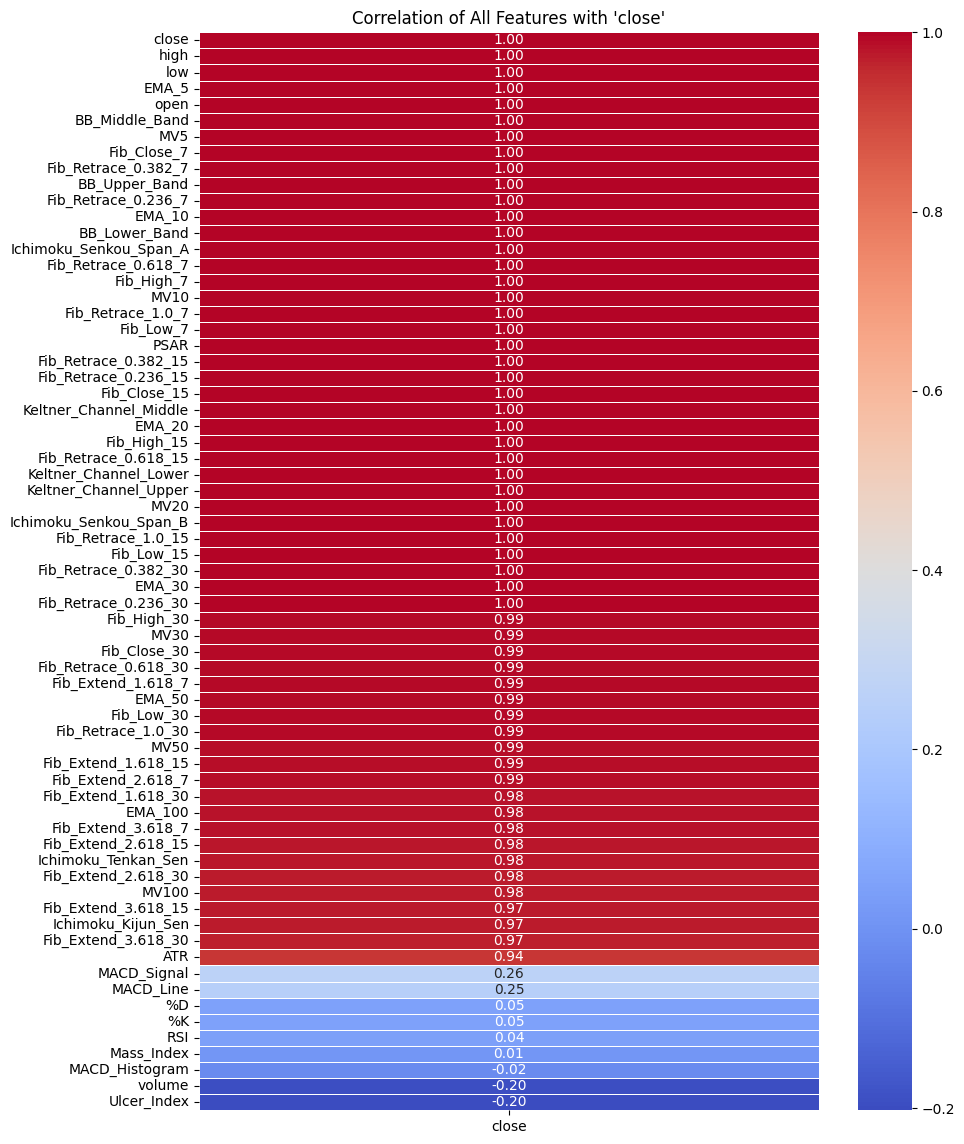

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation
numeric_df = coin_1h_data_with_ta.select_dtypes(include=['number'])

# Compute correlation matrix
correlation_matrix = numeric_df.corr()

# Sort correlations relative to 'close'
sorted_corr = correlation_matrix['close'].sort_values(ascending=False)

# Heatmap Showing Only Correlation with 'close'
plt.figure(figsize=(10, 14))
sns.heatmap(sorted_corr.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation of All Features with 'close'")
plt.show()


In [15]:
import numpy as np

# Keep only numeric columns
numeric_df = coin_1h_data_filled.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_df.corr().abs()

# Upper triangle mask (to avoid duplicate pairs)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation above threshold
threshold = 0.97
to_drop = [
    column for column in upper.columns
    if any(upper[column] > threshold) and column != 'close'
]

# Drop those features from the original dataframe
final_df = coin_1h_data_filled.drop(columns=to_drop)

print(f"Removed {len(to_drop)} highly correlated features:")
print(to_drop)


Removed 55 highly correlated features:
['high', 'low', 'MV5', 'MV10', 'MV20', 'MV30', 'MV50', 'MV100', 'EMA_5', 'EMA_10', 'EMA_20', 'EMA_30', 'EMA_50', 'EMA_100', 'Ichimoku_Tenkan_Sen', 'Ichimoku_Kijun_Sen', 'Ichimoku_Senkou_Span_A', 'Ichimoku_Senkou_Span_B', 'PSAR', 'BB_Lower_Band', 'BB_Middle_Band', 'BB_Upper_Band', 'Keltner_Channel_Lower', 'Keltner_Channel_Middle', 'Keltner_Channel_Upper', 'Fib_High_7', 'Fib_Low_7', 'Fib_Close_7', 'Fib_Retrace_0.236_7', 'Fib_Retrace_0.382_7', 'Fib_Retrace_0.618_7', 'Fib_Retrace_1.0_7', 'Fib_Extend_1.618_7', 'Fib_Extend_2.618_7', 'Fib_Extend_3.618_7', 'Fib_High_15', 'Fib_Low_15', 'Fib_Close_15', 'Fib_Retrace_0.236_15', 'Fib_Retrace_0.382_15', 'Fib_Retrace_0.618_15', 'Fib_Retrace_1.0_15', 'Fib_Extend_1.618_15', 'Fib_Extend_2.618_15', 'Fib_Extend_3.618_15', 'Fib_High_30', 'Fib_Low_30', 'Fib_Close_30', 'Fib_Retrace_0.236_30', 'Fib_Retrace_0.382_30', 'Fib_Retrace_0.618_30', 'Fib_Retrace_1.0_30', 'Fib_Extend_1.618_30', 'Fib_Extend_2.618_30', 'Fib_Extend_3

In [16]:
final_df

,timestamp,open,close,volume,symbol,MACD_Line,MACD_Histogram,MACD_Signal,RSI,%K,%D,ATR,Mass_Index,Ulcer_Index
0,2019-01-01,3698.19,3796.10,25877.070292,BTC/USDT,-86.702177,6.786925,-89.249377,37.557297,22.750691,23.211011,153.948436,23.903186,8.161039
1,2019-01-02,3796.10,3860.20,23309.033966,BTC/USDT,-86.702177,6.786925,-89.249377,37.557297,22.750691,23.211011,153.948436,23.903186,8.161039
2,2019-01-03,3860.20,3763.35,24296.479160,BTC/USDT,-86.702177,6.786925,-89.249377,37.557297,22.750691,23.211011,153.948436,23.903186,8.161039
3,2019-01-04,3763.35,3793.65,25463.623760,BTC/USDT,-86.702177,6.786925,-89.249377,37.557297,22.750691,23.211011,153.948436,23.903186,8.161039
4,2019-01-05,3793.65,3771.15,24982.097788,BTC/USDT,-86.702177,6.786925,-89.249377,37.557297,22.750691,23.211011,153.948436,23.903186,8.161039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6158,2025-04-12,121.41,132.23,680929.960000,SOL/USDT,-4.896706,1.682801,-6.579508,54.402456,64.730710,51.560927,11.475242,24.716135,16.770826
6159,2025-04-13,132.23,128.36,630742.930000,SOL/USDT,-3.859548,2.175968,-6.035516,51.866618,78.350851,65.113457,11.272011,24.900162,16.417749
6160,2025-04-14,128.36,129.41,691387.540000,SOL/USDT,-2.919216,2.493040,-5.412256,52.513370,84.869225,75.983595,11.048296,25.005636,16.036074
6161,2025-04-15,129.41,126.10,564562.240000,SOL/USDT,-2.413266,2.399192,-4.812458,50.222439,79.874521,81.031533,10.874846,25.124449,15.768917


## Label Encoding of Symbol Feature

In [17]:
from sklearn.preprocessing import LabelEncoder

# Initialize label encoder
le = LabelEncoder()

# Fit and transform the 'symbol' column
final_df['symbol_encoded'] = le.fit_transform(final_df['symbol'])

## Scale the features

In [18]:
from sklearn.preprocessing import StandardScaler

# Make a copy to avoid modifying original
df_scaled = final_df.copy()

# Columns to exclude from scaling
exclude_cols = ['symbol', 'symbol_encoded', 'timestamp'] if 'timestamp' in df_scaled.columns else ['symbol', 'symbol_encoded']

# Select numerical features to scale
numeric_cols = df_scaled.select_dtypes(include=['float64', 'int64']).columns
cols_to_scale = [col for col in numeric_cols if col not in exclude_cols]

# Initialize scaler
scaler = StandardScaler()

# Fit-transform the data
df_scaled[cols_to_scale] = scaler.fit_transform(df_scaled[cols_to_scale])


In [19]:
# df_scaled.to_csv('/content/drive/MyDrive/crypto price prediction/final_df.csv', index=False)

In [16]:
df_scaled = pd.read_csv('/content/drive/MyDrive/crypto price prediction/final_df.csv')

# Split the Data into Training and Testing

In [17]:
from sklearn.model_selection import train_test_split

# Drop unneeded columns
drop_cols = ['timestamp', 'symbol', 'close', 'volume']
X = df_scaled.drop(columns=drop_cols)
y = df_scaled['close']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

# Xgboost with hyperparameter

In [99]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
import numpy as np

In [105]:
# Define the model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Parameter grid
param_dist = {
    'n_estimators': [20, 50, 100],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
}

# Randomized Search
random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the model
random_search.fit(X_train, y_train)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=...
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None,
                                          random_state=42, ...),
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'n_estimators': [20, 50, 100]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [106]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_model = random_search.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# Print them
print("Evaluation Metrics:")
print(f"MAE   : {mae:.4f}")
print(f"MSE   : {mse:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"R2    : {r2:.4f}")
print(f"MAPE  : {mape:.2f}%")



Evaluation Metrics:
MAE   : 0.0136
MSE   : 0.0012
RMSE  : 0.0342
R2    : 0.9989
MAPE  : 1.85%


In [107]:
import matplotlib.pyplot as plt

# Get the label corresponding to BTC/USDT
btc_label = le.transform(['BTC/USDT'])[0]

# Create a mask for BTC/USDT in X_test
btc_mask = X_test['symbol_encoded'] == btc_label


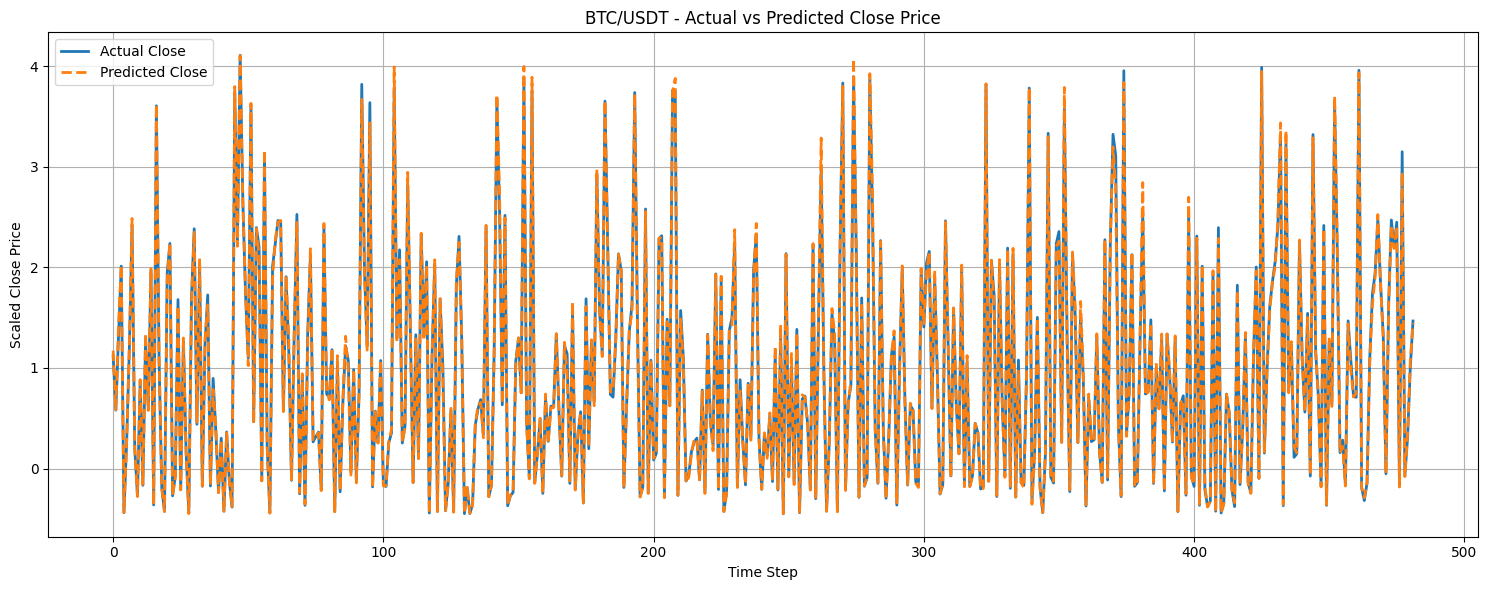

In [108]:
import matplotlib.pyplot as plt
import pandas as pd

# Get the label corresponding to BTC/USDT
btc_label = le.transform(['BTC/USDT'])[0]

# Find indices in X_test where symbol_encoded == btc_label
btc_indices = X_test[X_test['symbol_encoded'] == btc_label].index

# Filter actual and predicted values using these indices
btc_actual = y_test.loc[btc_indices].reset_index(drop=True)
btc_pred = pd.Series(y_pred, index=y_test.index).loc[btc_indices].reset_index(drop=True)

# Plot
plt.figure(figsize=(15, 6))
plt.plot(btc_actual, label='Actual Close', linewidth=2)
plt.plot(btc_pred, label='Predicted Close', linestyle='--', linewidth=2)
plt.title('BTC/USDT - Actual vs Predicted Close Price')
plt.xlabel('Time Step')
plt.ylabel('Scaled Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Random Forest

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV


In [110]:
# Define the Random Forest model
rf_model = RandomForestRegressor(random_state=42)

# Hyperparameter grid for Random Forest
param_dist_rf = {
    'n_estimators': [20, 50, 60],
    'max_depth': [None, 2, 5],
}

# Randomized search for Random Forest
random_search_rf = RandomizedSearchCV(
    rf_model,
    param_distributions=param_dist_rf,
    n_iter=5,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the model
random_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'max_depth': [None, 2, 5],
                                        'n_estimators': [20, 50, 60]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [111]:
# Get the best model
best_rf_model = random_search_rf.best_estimator_

# Predictions using the best model
y_pred_rf = best_rf_model.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

print("Random Forest Evaluation Metrics:")
print(f"MAE   : {mae_rf:.4f}")
print(f"MSE   : {mse_rf:.4f}")
print(f"RMSE  : {rmse_rf:.4f}")
print(f"R2    : {r2_rf:.4f}")
print(f"MAPE  : {mape_rf:.2f}%")

Random Forest Evaluation Metrics:
MAE   : 0.0130
MSE   : 0.0012
RMSE  : 0.0348
R2    : 0.9989
MAPE  : 1.72%


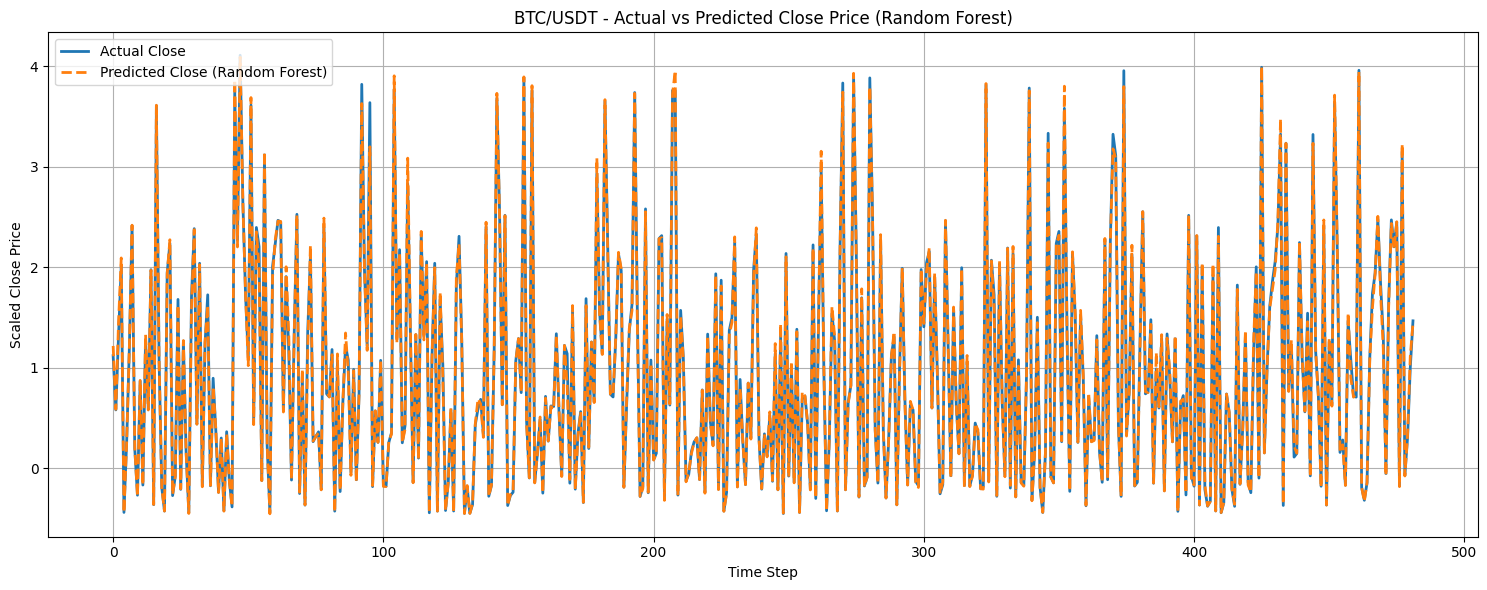

In [112]:
# Plotting for Random Forest (similar to XGBoost plot)
btc_pred_rf = pd.Series(y_pred_rf, index=y_test.index).loc[btc_indices].reset_index(drop=True)
plt.figure(figsize=(15, 6))
plt.plot(btc_actual, label='Actual Close', linewidth=2)
plt.plot(btc_pred_rf, label='Predicted Close (Random Forest)', linestyle='--', linewidth=2)
plt.title('BTC/USDT - Actual vs Predicted Close Price (Random Forest)')
plt.xlabel('Time Step')
plt.ylabel('Scaled Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
!pip uninstall -y keras keras-tuner tensorflow numpy

Found existing installation: keras 3.9.2
Uninstalling keras-3.9.2:
  Successfully uninstalled keras-3.9.2
Found existing installation: keras-tuner 1.4.7
Uninstalling keras-tuner-1.4.7:
  Successfully uninstalled keras-tuner-1.4.7
Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: numpy 2.1.3
Uninstalling numpy-2.1.3:
  Successfully uninstalled numpy-2.1.3


In [29]:
!pip install keras keras-tuner tensorflow

  Using cached keras-3.9.2-py3-none-any.whl.metadata (6.1 kB)
  Using cached keras_tuner-1.4.7-py3-none-any.whl.metadata (5.4 kB)
  Using cached tensorflow-2.19.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached numpy-2.1.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached keras-3.9.2-py3-none-any.whl (1.3 MB)
Using cached keras_tuner-1.4.7-py3-none-any.whl (129 kB)
Using cached tensorflow-2.19.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (644.9 MB)
Using cached numpy-2.1.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.3 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.11.0 requires tensorflow==2.18.0, but you have

In [18]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
import keras_tuner as kt

In [20]:

best_overall_model = None
best_overall_metrics = {'rmse': float('inf')}
best_overall_hp = None
best_time_step = None

def create_sequences(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

for time_step in [1, 3, 10]:
    print(f"\n⏱ Time Step = {time_step}")

    X_seq, y_seq = create_sequences(X, y, time_step)
    X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=True)

    def build_model(hp):
        model = keras.Sequential()
        model.add(keras.layers.LSTM(
            units=hp.Int('units', 32, 128, step=32),
            input_shape=(X_train.shape[1], X_train.shape[2]),
            return_sequences=False
        ))
        model.add(keras.layers.Dropout(rate=hp.Float('dropout', 0.1, 0.5, step=0.1)))
        model.add(keras.layers.Dense(1))
        model.compile(
            optimizer=keras.optimizers.Adam(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
            loss='mean_squared_error',
            metrics=['mae']
        )
        return model

    tuner = kt.RandomSearch(
        build_model,
        objective='val_loss',
        max_trials=5,
        directory='lstm_tuner',
        project_name=f'lstm_ts_{time_step}'
    )

    tuner.search(X_train, y_train, epochs=50, validation_split=0.2,
                 callbacks=[keras.callbacks.EarlyStopping(patience=3)], verbose=1)

    model = tuner.get_best_models(num_models=1)[0]
    y_pred = model.predict(X_test).flatten()

    # Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}, MAPE: {mape:.2f}%")

    if rmse < best_overall_metrics['rmse']:
        best_overall_model = model
        best_overall_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
        best_overall_metrics = {'rmse': rmse, 'mae': mae, 'mse': mse, 'r2': r2, 'mape': mape}
        best_y_test, best_y_pred = y_test, y_pred
        best_time_step = time_step


Trial 5 Complete [00h 00m 23s]
val_loss: 0.002301017055287957

Best val_loss So Far: 0.002301017055287957
Total elapsed time: 00h 01m 50s


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
RMSE: 0.0552, MAE: 0.0302, R²: 0.9968, MAPE: 5.12%


In [21]:
print("\n Best Hyperparameters:")
for param in best_overall_hp.values.keys():
    print(f"{param}: {best_overall_hp.get(param)}")


 Best Hyperparameters:
units: 32
dropout: 0.30000000000000004
learning_rate: 0.001


In [22]:
# Final Results
print(f"\n Best Time Step: {best_time_step}")
print(f"Final Evaluation Metrics (on test set):")
print(f"MAE   : {best_overall_metrics['mae']:.4f}")
print(f"MSE   : {best_overall_metrics['mse']:.4f}")
print(f"RMSE  : {best_overall_metrics['rmse']:.4f}")
print(f"R2    : {best_overall_metrics['r2']:.4f}")
print(f"MAPE  : {best_overall_metrics['mape']:.2f}%")


 Best Time Step: 10
Final Evaluation Metrics (on test set):
MAE   : 0.0302
MSE   : 0.0030
RMSE  : 0.0552
R2    : 0.9968
MAPE  : 5.12%


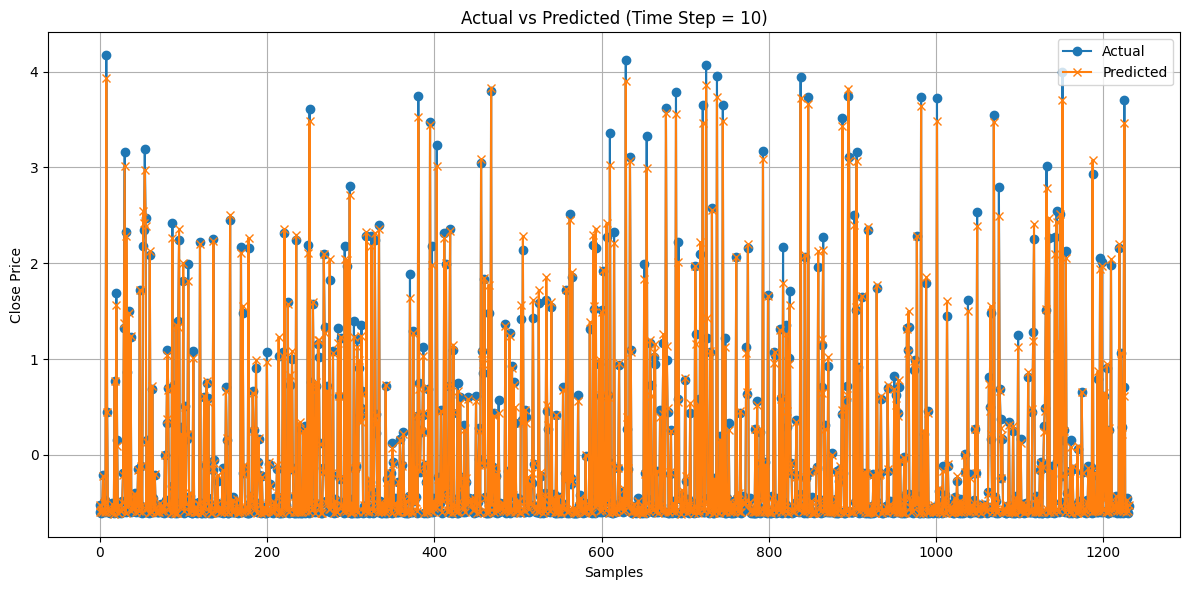

In [23]:
# Visualization
plt.figure(figsize=(12, 6))
plt.plot(best_y_test, label='Actual', marker='o')
plt.plot(best_y_pred, label='Predicted', marker='x')
plt.title(f'Actual vs Predicted (Time Step = {best_time_step})')
plt.xlabel('Samples')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
